# Notebook Settings

In [1]:
import os
import sys
from pathlib import Path

# Automatically set working directory to root directory
if Path.cwd().name == 'model_building':
    PROJECT_PATH = Path.cwd().parent
else:
    PROJECT_PATH = Path.cwd()

os.chdir(PROJECT_PATH)

if str(PROJECT_PATH) not in sys.path:
    sys.path.append(str(PROJECT_PATH))

print(f"Working directory set to: {os.getcwd()}")

# 3. Core imports and configuration
from source.config import *
import pandas as pd
from source.helper import *
%run "./model_building/3_parked_functions_V1.ipynb"

print("All imports executed perfectly!")

# 4. Display options
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.width', 1000)

Working directory set to: c:\Users\mail2\OneDrive\coding projects\Final Project
[Logs] Project is on OneDrive. Writing tuner/TB logs locally to:
       C:\Users\mail2\AppData\Local\cqf_quant_model_logs
All imports executed perfectly!


# Data Import

In [2]:
# read data
df_raw = getdata('15Yrs_60Min')
print(f'top five rows:\n{df_raw.head()}\n')
print(f'bottom five rows:\n{df_raw.tail()}\n')
print(f'Number of missing values:\n{df_raw.isna().sum()}\n')
print(f'Shape of the DataFrame: {df_raw.shape}')

top five rows:
                        open     high      low    close  volume    days    hours
datetime                                                                        
2015-01-09 09:15:00  8285.45  8303.00  8273.95  8281.55     0.0  Friday  morning
2015-01-09 10:15:00  8281.50  8291.45  8277.95  8282.35     0.0  Friday  morning
2015-01-09 11:15:00  8282.55  8283.20  8191.10  8221.85     0.0  Friday  morning
2015-01-09 12:15:00  8222.85  8272.60  8198.40  8245.85     0.0  Friday     noon
2015-01-09 13:15:00  8246.70  8251.65  8204.75  8225.20     0.0  Friday     noon

bottom five rows:
                         open      high       low     close  volume      days    hours
datetime                                                                              
2023-09-14 10:15:00  20113.10  20123.80  20064.30  20097.50     0.0  Thursday  morning
2023-09-14 11:15:00  20097.00  20105.90  20069.25  20096.05     0.0  Thursday  morning
2023-09-14 12:15:00  20098.45  20102.45  20050.60  

# Feature Engineering

### Generate features from Pandas_TA

In [3]:
print(f"Data successfully loaded. Original shape: {df_raw.shape}")

print("Dynamically compiling and executing filtered feature matrix...")
#df_final = DayTransformer().fit_transform(df_raw)
#df_final = TimeTransformer().fit_transform(df_final)
df_final = generate_all_ta_features(df_raw)


print(f"\nSuccess! Generated a total feature matrix of {len(df_final.columns)} columns.")
print(f"Total usable data rows remaining: {len(df_final)}")
print(df_final.head())

Data successfully loaded. Original shape: (15000, 7)
Dynamically compiling and executing filtered feature matrix...
[!] VWAP requires an ordered DatetimeIndex.

Success! Generated a total feature matrix of 218 columns.
Total usable data rows remaining: 14999
                        open     high      low    close  volume    days    hours  EBSW  REFLEX  AO  APO  BIAS  CCI  CFO  CG  ...  OBVe_12  AOBV_LR_2  AOBV_SR_2  EFI  KVO_34_55_13  KVOs_34_55_13  MFI     NVI    PVI  PVIe_255  PVOL  PVR  PVT  TSV_18_10  TSVs_18_10
datetime                                                                                                                     ...                                                                                                                                      
2015-01-09 09:15:00  8285.45  8303.00  8273.95  8281.55     0.0  Friday  morning   NaN     NaN NaN  NaN   NaN  NaN  NaN NaN  ...      NaN          0          0  NaN           NaN            NaN  NaN  1000.0  100.0  

### Remove low quality features

In [4]:
# 1. Define target (label)
data = df_final.copy()
future_return = (data['close'].shift(-5) - data['close']) / data['close']
data['predict'] = np.where(future_return > 0.0025, 1, 0)

# remove warmup periods and future-prediction overlap
data = data[200:-5]

# 2. Dynamically drop bad columns
# This drops any column that is more than 30% NaNs/Infs, and any column with std = 0
data = drop_low_quality_columns(data, missing_threshold=0.10, drop_zero_std=True)

# 3. Clean up whatever sparse NaNs are left in the remaining good columns
data.ffill(axis=0, inplace=True)
data.bfill(axis=0, inplace=True)
data.dropna(inplace=True)

# verify cleanliness
print(f"\nMatrix shape after cleaning: {data.shape}")
print(f"Remaining infinite or NaN values: {data.isna().sum().sum()}")

Dropped 40 columns total.
 -> 11 due to >10.0% missing data.
 -> 23 due to 0 standard deviation.
 -> 6 due to non_stationary.

Matrix shape after cleaning: (14794, 179)
Remaining infinite or NaN values: 0


In [5]:
#data.isna().sum().sort_values(ascending=False).head(10)

### Descriptive Summary

In [6]:
data.describe().T.head(20).style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
EBSW,14794.00,0.13,0.91,-1.00,-0.97,0.77,0.99,1.00
REFLEX,14794.00,-0.01,0.99,-2.87,-0.76,-0.05,0.72,3.10
AO,14794.00,10.89,136.86,-1045.76,-60.06,22.01,86.95,637.57
APO,14794.00,5.26,75.70,-460.70,-33.36,10.05,46.85,437.53
BIAS,14794.00,0.00,0.01,-0.17,-0.01,0.00,0.01,0.09
CCI,14794.00,10.43,111.64,-464.60,-81.48,25.26,98.87,413.41
CFO,14794.00,-0.00,0.38,-7.65,-0.19,-0.02,0.17,4.82
CG,14794.00,-5.50,0.01,-5.61,-5.51,-5.50,-5.49,-5.35
CMO,14794.00,5.38,29.13,-80.14,-16.26,7.94,27.46,78.60
COPPOCK,14794.00,0.16,2.47,-18.99,-1.14,0.32,1.51,20.37


In [7]:
#data.to_csv(PROJECT_PATH + '/data/data_ta_indicator.csv')
#data.describe().T.round(2).to_csv(PROJECT_PATH + '/data/all_indicator_description.csv')

### Class Frequancy and Imbalence

In [8]:
# class frequency
c = data['predict'].value_counts()
c

predict
0    9201
1    5593
Name: count, dtype: int64

### Class weight

In [9]:
# # check class weights
class_weight = cwts(data, target_col='predict')
class_weight

{0: np.float64(0.8039343549614173), 1: np.float64(1.3225460396924726)}

In [10]:
# With the calculated weights, both classes gain equal weight
class_weight[0] * c[0], class_weight[1] * c[1]

(np.float64(7397.000000000001), np.float64(7396.999999999999))

### Prepare dataset for model

In [11]:
X = data.drop('predict', axis=1)
feature_names = X.columns
print(X.tail())

                         EBSW    REFLEX          AO        APO      BIAS         CCI       CFO        CG        CMO   COPPOCK       CRSI       CTI        ER   BULLP_13   BEARP_13  ...       HWW_1   HWPCT_1     KCLe_20_2     KCBe_20_2     KCUe_20_2      MASSI      NATR        RVI  THERMO_20_2_0.5  THERMOma_20_2_0.5  THERMOl_20_2_0.5  THERMOs_20_2_0.5  TRUE_RANGE        UI  PVR
datetime                                                                                                                                                                            ...                                                                                                                                                                                                   
2023-09-13 11:15:00  0.996308 -1.114330  160.012647  84.981410  0.006540  170.757496  0.162767 -5.501282  46.857069  1.020490  78.317977  0.319216  0.196449  70.044050  16.194050  ...  134.424140  0.219016  19831.017128  19939.128086  20047.2

In [12]:
y = data['predict'].values
# pandas-ta converts all dtype to objects
y = y.astype(int)
y

array([0, 0, 1, ..., 0, 0, 0], shape=(14794,))

In [13]:
# Always keep shuffle = False for financial time series
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, shuffle=False)

# convert to array
X_train, X_test, y_train, y_test = np.array(X_train), np.array(X_test), np.array(y_train), np.array(y_test)

# Output the train and test data size
print(f"Train and Test Size {len(X_train)}, {len(X_test)}")

Train and Test Size 8876, 5918


# Feature Engineering: Baseline Models

### Feature Engineering: Random Forest Baseline Model

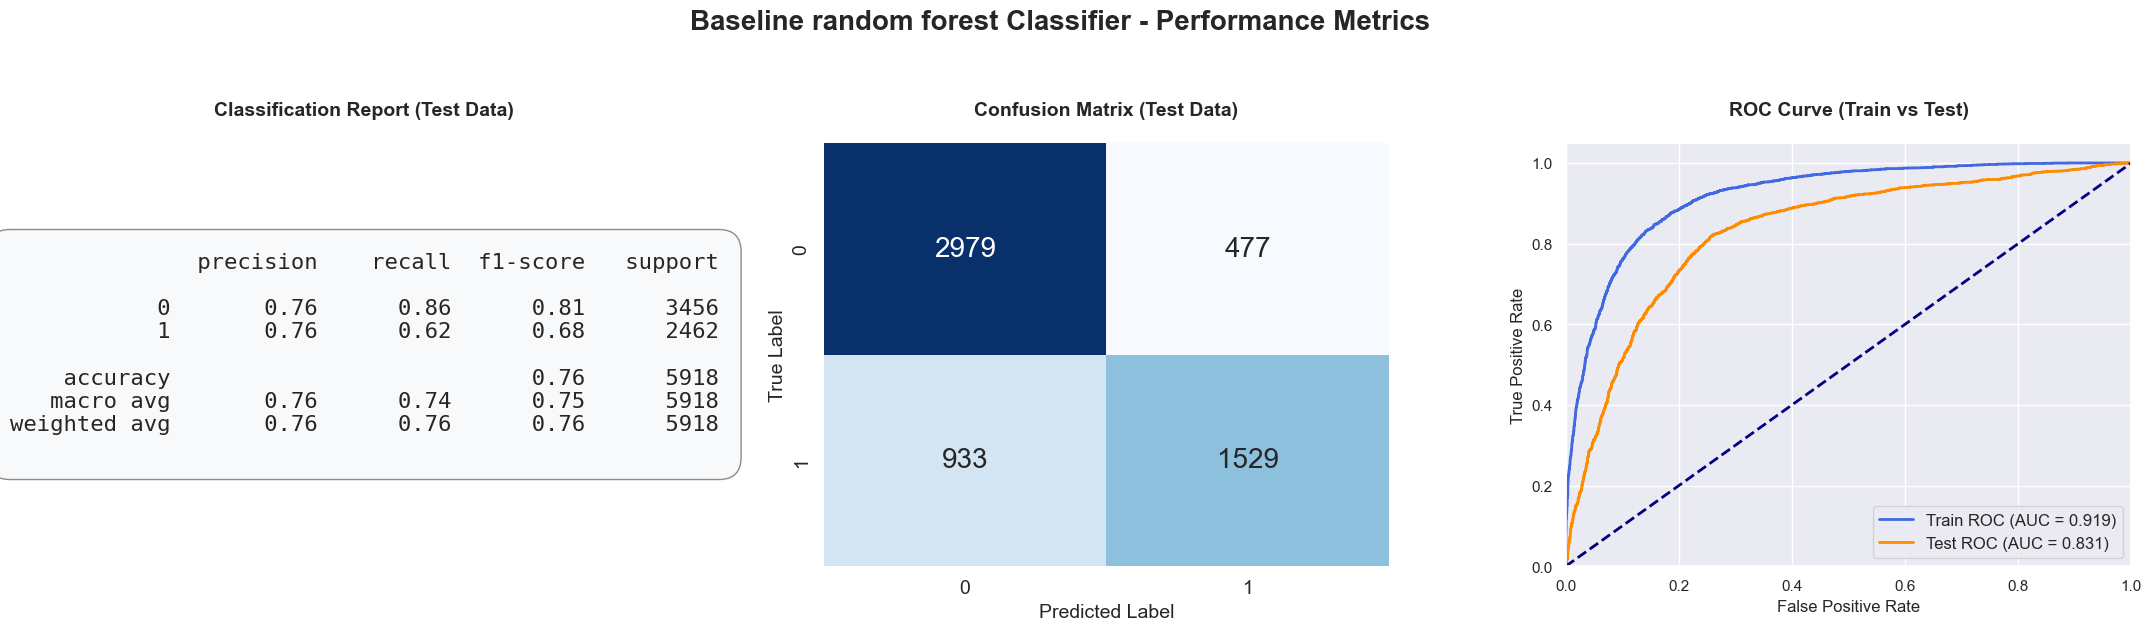

In [14]:
forest = RandomForestClassifier(n_jobs=-1, class_weight=class_weight,random_state=42, max_depth=5)
forest.fit(X_train, y_train)
#print("Accuracy Score \t\t", accuracy_score(y_test, forest.predict(X_test)))
plot_ml_model_performance(model=forest, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, model_name="Baseline random forest Classifier")

### Feature Engineering: XGBoost Baseline Model

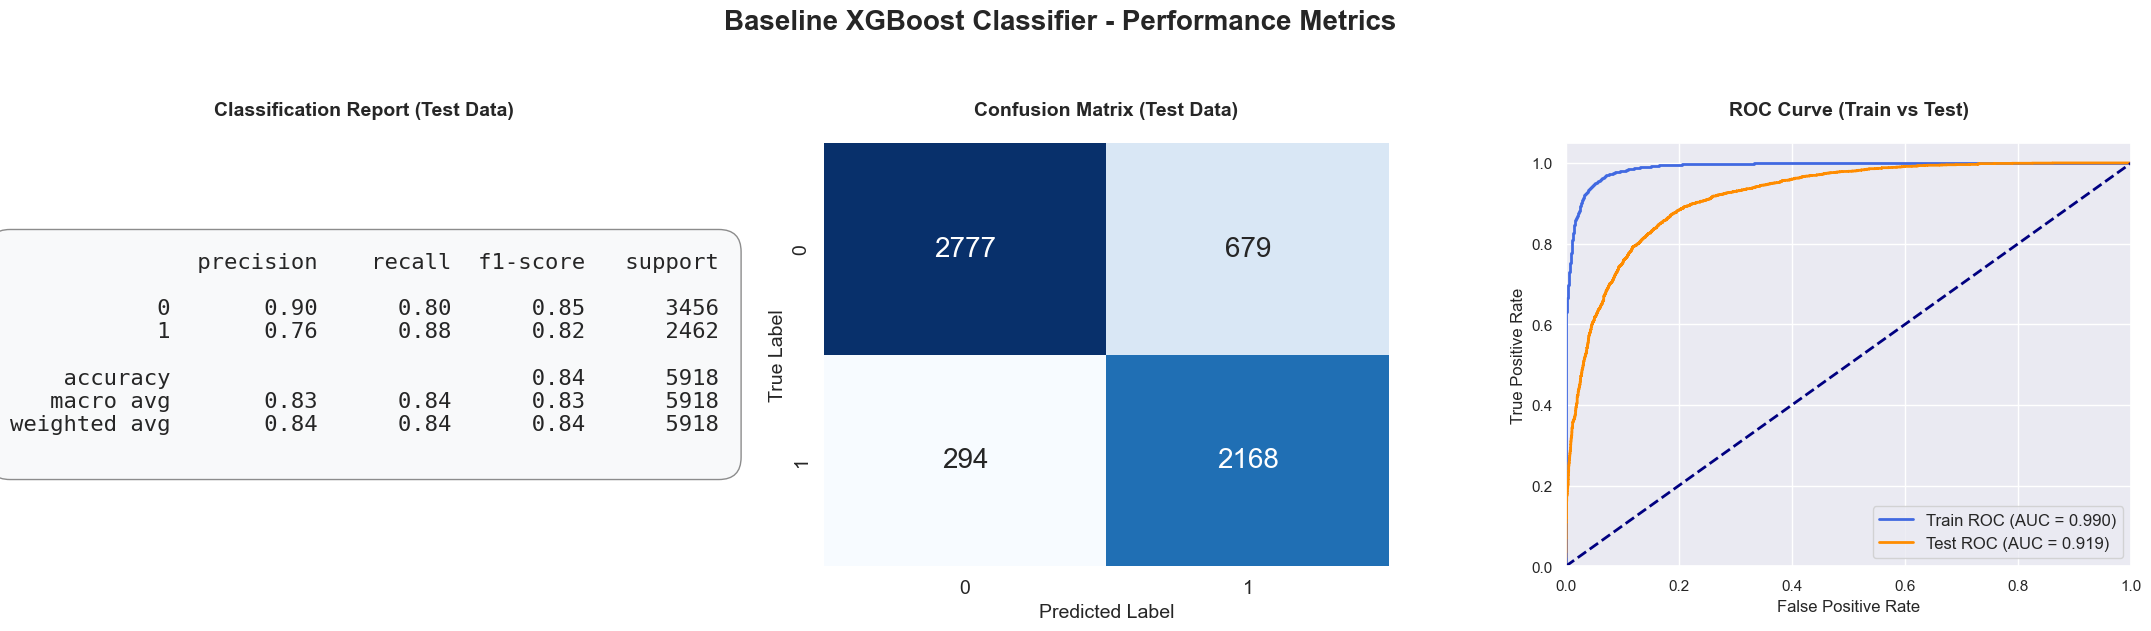

In [15]:
# convert class_weight dict to sample weights per row
sample_weight = np.where(y_train == 1, class_weight[1], class_weight[0])

xgb_model = xgb.XGBClassifier(
    n_estimators=500,          # Higher trees...
    learning_rate=0.05,        # ...but slower, smaller learning steps
    max_depth=4,               # Shallower trees
    min_child_weight=5,        # Require more evidence to split nodes
    subsample=0.8,             # Use 80% of rows per tree
    colsample_bytree=0.8,      # Use 80% of columns per tree
    gamma=1,                   # Minimum loss reduction to split
    reg_lambda=2,              # L2 regularization
    n_jobs=-1,
    random_state=42
)

# Train the model (no extra sample weights needed in fit)
xgb_model.fit(X_train, y_train, sample_weight = sample_weight)

# Call the function for your XGBoost model
plot_ml_model_performance(model=xgb_model, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, model_name="Baseline XGBoost Classifier")


### Feature Selection based on Baseline Models
Feature selection methods are approaches to reduce the number of input variables that are believed to be most useful to a model. It is primarily focused on removing non-informative or redundant predictors from the model. While there are a few methods, we'll focus on Boruta for this workshop.

### Boruta Algorithm for Feature Selection
Bortua algorithm is designed to take the “all-relevant” approach to feature selection. It is a wrapper built around the random forest classification algorithm which is relatively quick and can run without tuning of parameters and it gives a numerical estimate of the feature importance.

Importance measure of an attribute is obtained as the loss of accuracy of classification caused by the random permutation of attribute values between objects.

Due to the fact that the number of random forest runs during Boruta is limited by the max_iter argument, the calculation can be forced to stop prematurely, when there are still attributes which are judged neither to be confirmed nor rejected — and thus finally marked tentative.

In [16]:
# define Boruta feature selection method
feat_selector = BorutaPy(xgb_model, n_estimators='auto', verbose=2, random_state=42, max_iter=100)

# find all relevant features and print the live results
feat_selector.fit(X_train, y_train)

# call transform() on X to filter it down to selected features
X_filtered = feat_selector.transform(X_train)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	178
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	178
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	178
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	178
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	178
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	178
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	178
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	22
Tentative: 	117
Rejected: 	39
Iteration: 	9 / 100
Confirmed: 	22
Tentative: 	117
Rejected: 	39
Iteration: 	10 / 100
Confirmed: 	22
Tentative: 	117
Rejected: 	39
Iteration: 	11 / 100
Confirmed: 	22
Tentative: 	117
Rejected: 	39
Iteration: 	12 / 100
Confirmed: 	26
Tentative: 	101
Rejected: 	51
Iteration: 	13 / 100
Confirmed: 	26
Tentative: 	101
Rejected: 	51
Iteration: 	14 / 100
Confirmed: 	26
Tentative: 	101
Rejected: 	51
Iteration: 	15 / 100
Confirmed: 	26
Tentative: 	101
Rejected: 	51
Iteration: 	16 / 100
Confirmed: 	

### Ranking of each Features for Selection Purpose

In [17]:
# zip feature names, ranks, and decisions in a single iterable
feature_ranks = list(zip(feature_names, feat_selector.ranking_, feat_selector.support_))

# iterate through and print out the results
for feat in feature_ranks:
    print(f'Feature: {feat[0]:<40} Rank: {feat[1]:<15} Keep: {feat[2]}')

Feature: EBSW                                     Rank: 12              Keep: False
Feature: REFLEX                                   Rank: 30              Keep: False
Feature: AO                                       Rank: 45              Keep: False
Feature: APO                                      Rank: 49              Keep: False
Feature: BIAS                                     Rank: 1               Keep: True
Feature: CCI                                      Rank: 1               Keep: True
Feature: CFO                                      Rank: 2               Keep: False
Feature: CG                                       Rank: 1               Keep: True
Feature: CMO                                      Rank: 1               Keep: True
Feature: COPPOCK                                  Rank: 69              Keep: False
Feature: CRSI                                     Rank: 1               Keep: True
Feature: CTI                                      Rank: 72              Keep: Fal

### Selected Features

In [18]:
selected_rf_features = pd.DataFrame({'Feature':feature_names, 'Ranking':feat_selector.ranking_})
myfeature_export = selected_rf_features[selected_rf_features['Ranking']==1]
print(f'Number of feature retained: {myfeature_export.shape[0]}\n')
print(myfeature_export)

Number of feature retained: 40

                         Feature  Ranking
4                           BIAS        1
5                            CCI        1
7                             CG        1
8                            CMO        1
10                          CRSI        1
13                      BULLP_13        1
14                      BEARP_13        1
22                         J_9_3        1
23   KST_10_15_20_30_10_10_10_15        1
29                           PGO        1
36                           ROC        1
39                         SLOPE        1
40                SMI_5_20_5_1.0        1
42               SMIo_5_20_5_1.0        1
56                 STOCHh_14_3_3        1
57                  STOCHFk_14_3        1
58                  STOCHFd_14_3        1
62                    TRIXs_30_9        1
64                 TSIs_13_25_13        1
65                            UO        1
66                         WILLR        1
77                           HMA        1
10

In [19]:
# # 2. Extract the string names into a standard Python list and filter main dataset
# features_to_keep = myfeature_export['Feature'].tolist()
# df_lstm_ready = X[features_to_keep].copy()

# # add 'close', and 'Target' for future analysis purpose
# df_lstm_ready['close'] = df_final['close']
# df_lstm_ready['Target'] = y
# print(df_lstm_ready.head())

# 5. Export for your deep learning notebook
#df_lstm_ready.to_csv(PROJECT_PATH / "data/lstm_training_data.csv")

### Review the optimized dataset with selected features

In [20]:
features_to_keep = myfeature_export['Feature'].tolist()
df_boruta  = X[features_to_keep]
df_boruta['Target'] = y
print(df_boruta.head())

                         BIAS         CCI        CG        CMO       CRSI   BULLP_13   BEARP_13      J_9_3  KST_10_15_20_30_10_10_10_15       PGO       ROC  SLOPE  SMI_5_20_5_1.0  SMIo_5_20_5_1.0  STOCHh_14_3_3  ...      DMN_14  AMATe_LR_8_21_2  AMATe_SR_8_21_2  CKSPs_10_3_20     DPO  ABER_ATR_5_15        ATR  BBB_5_2.0_2.0  BBP_5_2.0_2.0   HWPCT_1      NATR        RVI  THERMO_20_2_0.5  THERMOma_20_2_0.5  Target
datetime                                                                                                                                                                                                            ...                                                                                                                                                                                                        
2015-02-23 13:15:00 -0.008311 -227.893745 -5.494851 -19.685059  14.774476  18.086152 -69.413848  12.619482                   391.832015 -1.955680 -0.779510 -74.25      

### Quality Check: Rerun the model (XBBoost) with selected features

In [21]:
print(f'shape of the X_train_filtered: {X_filtered.shape}\n')
X_test_filtered = feat_selector.transform(X_test)
print(f'shape of the X_test_filtered: {X_test_filtered.shape}\n')
print(f'feature list: \n{features_to_keep}\n')
xgb_model.fit(X_filtered, y_train)

shape of the X_train_filtered: (8876, 40)

shape of the X_test_filtered: (5918, 40)

feature list: 
['BIAS', 'CCI', 'CG', 'CMO', 'CRSI', 'BULLP_13', 'BEARP_13', 'J_9_3', 'KST_10_15_20_30_10_10_10_15', 'PGO', 'ROC', 'SLOPE', 'SMI_5_20_5_1.0', 'SMIo_5_20_5_1.0', 'STOCHh_14_3_3', 'STOCHFk_14_3', 'STOCHFd_14_3', 'TRIXs_30_9', 'TSIs_13_25_13', 'UO', 'WILLR', 'HMA', 'LOG_RETURN', 'PERCENT_RETURN', 'ZSCORE', 'DMP_14', 'DMN_14', 'AMATe_LR_8_21_2', 'AMATe_SR_8_21_2', 'CKSPs_10_3_20', 'DPO', 'ABER_ATR_5_15', 'ATR', 'BBB_5_2.0_2.0', 'BBP_5_2.0_2.0', 'HWPCT_1', 'NATR', 'RVI', 'THERMO_20_2_0.5', 'THERMOma_20_2_0.5']



,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,feature_types,None


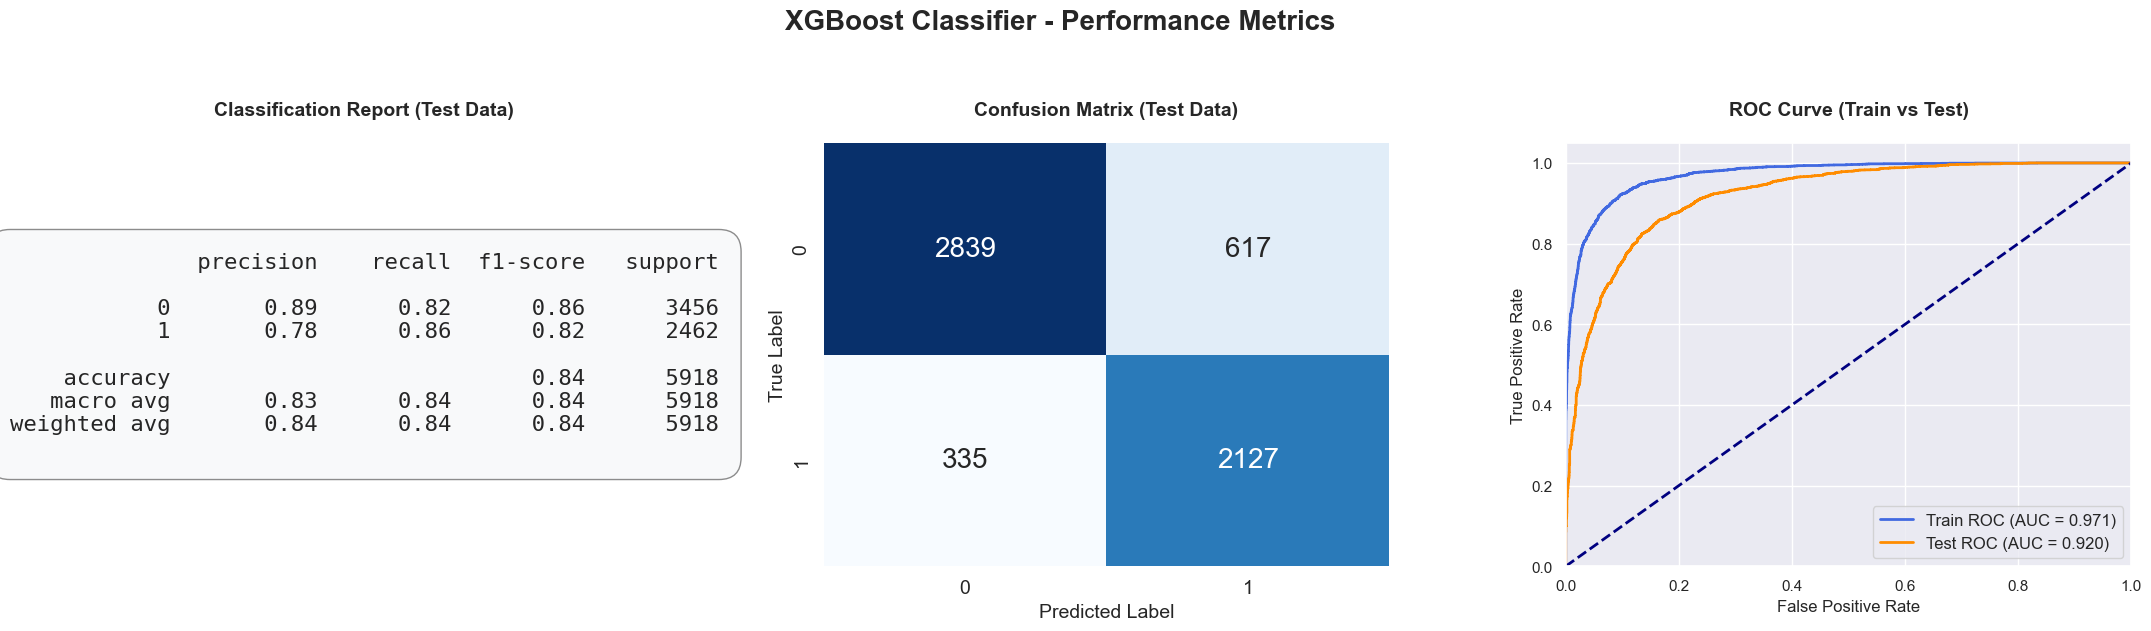

In [22]:
# Train the model (no extra sample weights needed in fit)
#xgb_model.fit(X_filtered, y_train)

# Call the function for your XGBoost model
plot_ml_model_performance(model=xgb_model, X_train=X_filtered, y_train=y_train, X_test=X_test_filtered, y_test=y_test, model_name="XGBoost Classifier")

# Systematic Scalling

### Separate X and y

In [23]:
#1. Separate X and y variables. y, the target is already defined in ealier steps in pipeline
y = df_boruta['Target']
X = df_boruta.drop('Target', axis=1)

#3. Define the class weights. y variable is not balanced ideally for a model to work on. Important to control the majority class bias
c= np.bincount(y)
class_weight = cwts(y)
print(f'the bins in target variable: {c}')
print(f'class weight in target variable: {class_weight}')
print(f'With the calculated weights, both classes gain equal weight {class_weight[0] * c[0], class_weight[1] * c[1]}')

print(f'shape of X variables {X.shape}\n')
print(f'list of columns in X: \n {list(X.columns)}\n')

print(f'top 5 row of of input dataframe \n{X.head()}')

the bins in target variable: [9201 5593]
class weight in target variable: {0: np.float64(0.8039343549614173), 1: np.float64(1.3225460396924726)}
With the calculated weights, both classes gain equal weight (np.float64(7397.000000000001), np.float64(7396.999999999999))
shape of X variables (14794, 40)

list of columns in X: 
 ['BIAS', 'CCI', 'CG', 'CMO', 'CRSI', 'BULLP_13', 'BEARP_13', 'J_9_3', 'KST_10_15_20_30_10_10_10_15', 'PGO', 'ROC', 'SLOPE', 'SMI_5_20_5_1.0', 'SMIo_5_20_5_1.0', 'STOCHh_14_3_3', 'STOCHFk_14_3', 'STOCHFd_14_3', 'TRIXs_30_9', 'TSIs_13_25_13', 'UO', 'WILLR', 'HMA', 'LOG_RETURN', 'PERCENT_RETURN', 'ZSCORE', 'DMP_14', 'DMN_14', 'AMATe_LR_8_21_2', 'AMATe_SR_8_21_2', 'CKSPs_10_3_20', 'DPO', 'ABER_ATR_5_15', 'ATR', 'BBB_5_2.0_2.0', 'BBP_5_2.0_2.0', 'HWPCT_1', 'NATR', 'RVI', 'THERMO_20_2_0.5', 'THERMOma_20_2_0.5']

top 5 row of of input dataframe 
                         BIAS         CCI        CG        CMO       CRSI   BULLP_13   BEARP_13      J_9_3  KST_10_15_20_30_10_10

### Review the dataset to be used for backtesting purpose

In [24]:
# dataframe to be used for backtesting purpose
df_boruta['close'] = df_final['close']
df_boruta['Target'] = y
print(df_boruta.head())
print(df_boruta.shape)

                         BIAS         CCI        CG        CMO       CRSI   BULLP_13   BEARP_13      J_9_3  KST_10_15_20_30_10_10_10_15       PGO       ROC  SLOPE  SMI_5_20_5_1.0  SMIo_5_20_5_1.0  STOCHh_14_3_3  ...  AMATe_LR_8_21_2  AMATe_SR_8_21_2  CKSPs_10_3_20     DPO  ABER_ATR_5_15        ATR  BBB_5_2.0_2.0  BBP_5_2.0_2.0   HWPCT_1      NATR        RVI  THERMO_20_2_0.5  THERMOma_20_2_0.5  Target    close
datetime                                                                                                                                                                                                            ...                                                                                                                                                                                                     
2015-02-23 13:15:00 -0.008311 -227.893745 -5.494851 -19.685059  14.774476  18.086152 -69.413848  12.619482                   391.832015 -1.955680 -0.779510 -74.25       -0.09

In [25]:
# ===========================================================
# 1. DATA SPLITTING & PREPARATION and BASELINE INITIALIZATION
# ===========================================================
# 1. Standard 2-Way Chronological Split (80% Train, 20% Test)
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.4, shuffle=False)
print(f"Data Split -> Train: {Xtrain.shape[0]}, Test: {Xtest.shape[0]}")

# 2. Identify the feature columns, remove the non-features
features = [col for col in Xtrain.columns if col.upper() not in ['CLOSE', 'TARGET', 'PREDICT', 'VOLUME']]

# 3. Initialize all features with MinMaxScaler as baseline
print("\nInitializing Baseline (All MinMaxScaler)...")
current_best_scalers = {col: 'MinMaxScaler' for col in features}

# Fixed seed for reproducible scaler search
SCALER_SEARCH_SEED = 42

# 4. Baseline preprocessing setup before the optimization loop begins
X_tr_scaled, X_te_scaled = apply_scalers(current_best_scalers, Xtrain, Xtest)

# 5. Train Light LSTM baseline with fixed seed
best_score, best_loss = build_and_train_intermediate_lstm(
    X_tr_scaled, ytrain, X_te_scaled, ytest, class_weight, seed=SCALER_SEARCH_SEED
)
print(f"Baseline Score (Validation Accuracy): {best_score:.4f}")
print(f"Baseline Loss: {best_loss:.4f}")

# ==========================================
# 2. GREEDY OPTIMIZATION LOOP
# ==========================================
scalers_to_test = ['MinMaxScaler', 'StandardScaler', 'RobustScaler']
EPS = 1e-6

# 1. Swap scaler (StandardScaler, RobustScaler) for each feature
for col in features:
    print(f"\nOptimizing Feature: {col}")
    feature_best_scaler = current_best_scalers[col]
    feature_best_score = best_score
    feature_best_loss = best_loss

    # 2. Apply scaler after swapping and train/evaluate Light LSTM
    for test_scaler in scalers_to_test:
        if test_scaler == current_best_scalers[col]:
            continue  # Skip if the scaler is already the current best for this feature

        test_dict = current_best_scalers.copy()
        test_dict[col] = test_scaler

        X_tr_temp, X_te_temp = apply_scalers(test_dict, Xtrain, Xtest)
        score, val_loss = build_and_train_intermediate_lstm(
            X_tr_temp, ytrain, X_te_temp, ytest, class_weight, seed=SCALER_SEARCH_SEED
        )
        print(f"  Tested {test_scaler} -> Score: {score:.4f}, Loss: {val_loss:.4f}")

        # 3. Keep scaler if score improves; if score ties, choose lower validation loss
        score_better = score > (feature_best_score + EPS)
        tie_on_score = abs(score - feature_best_score) <= EPS
        loss_better = val_loss < (feature_best_loss - EPS)
        if score_better or (tie_on_score and loss_better):
            print(f"  *** New Best Found for {col}: {test_scaler}! ***")
            feature_best_score = score
            feature_best_loss = val_loss
            feature_best_scaler = test_scaler

    current_best_scalers[col] = feature_best_scaler
    best_score = feature_best_score
    best_loss = feature_best_loss

print("\n--- Final Optimized Scaler Dictionary ---")
print(current_best_scalers)
print(f"Final Best Score: {best_score:.4f}")

# ==========================================
# 3. FINAL PIPELINE FOR PRODUCTION MODEL
# ==========================================
# 1. Apply best scaler configuration to full training set
scaler_groups = {'MinMaxScaler': [], 'RobustScaler': [], 'StandardScaler': []}
for col in features:
    assigned_scaler = current_best_scalers.get(col, 'RobustScaler')
    scaler_groups[assigned_scaler].append(col)

# 2. Fit ColumnTransformer & transform Train/Test sets
final_ct = ColumnTransformer(
    transformers=[
        ('minmax', MinMaxScaler(), scaler_groups['MinMaxScaler']),
        ('robust', RobustScaler(), scaler_groups['RobustScaler']),
        ('standard', StandardScaler(), scaler_groups['StandardScaler'])],
    remainder='drop'
)

# Fit on training data only, then transform both Train and Test
scaled_train_final = final_ct.fit_transform(Xtrain)
scaled_test_final = final_ct.transform(Xtest)

SEQLEN = 21

# 3. Wrap scaled data into Keras TimeseriesGenerators
final_train_gen = TimeseriesGenerator(scaled_train_final, ytrain.values, length=SEQLEN)
final_test_gen = TimeseriesGenerator(scaled_test_final, ytest.values, length=SEQLEN)

print(f"Generators Ready -> Train: {len(final_train_gen)}, Test: {len(final_test_gen)}")

Data Split -> Train: 8876, Test: 5918

Initializing Baseline (All MinMaxScaler)...

Baseline Score (Validation Accuracy): 0.5852
Baseline Loss: 0.6733

Optimizing Feature: BIAS
  Tested StandardScaler -> Score: 0.5781, Loss: 0.6847
  Tested RobustScaler -> Score: 0.5771, Loss: 0.6847

Optimizing Feature: CCI
  Tested StandardScaler -> Score: 0.5698, Loss: 0.6858
  Tested RobustScaler -> Score: 0.5632, Loss: 0.6865

Optimizing Feature: CG
  Tested StandardScaler -> Score: 0.5767, Loss: 0.6860
  Tested RobustScaler -> Score: 0.5800, Loss: 0.6859

Optimizing Feature: CMO
  Tested StandardScaler -> Score: 0.5706, Loss: 0.6842
  Tested RobustScaler -> Score: 0.5771, Loss: 0.6836

Optimizing Feature: CRSI
  Tested StandardScaler -> Score: 0.5528, Loss: 0.6871
  Tested RobustScaler -> Score: 0.5520, Loss: 0.6869

Optimizing Feature: BULLP_13
  Tested StandardScaler -> Score: 0.5510, Loss: 0.6876
  Tested RobustScaler -> Score: 0.5537, Loss: 0.6873

Optimizing Feature: BEARP_13
  Tested Standa

In [26]:
pd.Series(current_best_scalers).value_counts()

MinMaxScaler      34
RobustScaler       4
StandardScaler     2
Name: count, dtype: int64

In [27]:
# Save the raw 2D feature arrays (not the already-windowed arrays)
save_dir = PROJECT_PATH / "data"
save_dir.mkdir(exist_ok=True)

np.savez(
    save_dir / "lstm_sequences.npz",
    X_train=scaled_train_final,
    y_train=ytrain.values,
    X_test=scaled_test_final,
    y_test=ytest.values,
    seq_len=SEQLEN
)

df_boruta.to_pickle(save_dir / "df_boruta.pkl")

print("Saved raw LSTM training data to:", save_dir / "lstm_sequences.npz")

Saved raw LSTM training data to: c:\Users\mail2\OneDrive\coding projects\Final Project\data\lstm_sequences.npz


### Persist the fitted feature-selection & scaling pipeline
The Boruta-confirmed feature list and the fitted `ColumnTransformer` (`final_ct`) only make sense if reused exactly as fit here — refitting a scaler on new/incoming data would silently change what the trained models expect as input. This cell saves both artifacts to disk so any new raw OHLCV file can be transformed identically (no refitting) before being scored by the model(s) trained in `2_model_building.ipynb`. Used by `source/end_to_end_pipeline/raw_data_to_signal.ipynb`.

In [28]:
import joblib

fe_pipeline_artifacts = {
    "features_to_keep": features_to_keep,   # Boruta-confirmed feature names (selected by name, order-independent)
    "scaler": final_ct,                     # fitted ColumnTransformer (MinMax/Robust/Standard groups), fit on train split only
    "seqlen": SEQLEN,
    "target_horizon_bars": 5,                # matches future_return = close.shift(-5)
    "target_threshold": 0.0025,              # matches predict = future_return > 0.0025
    "warmup_trim": 200,                      # matches data[200:-5]
    "horizon_trim": 5,
}

save_dir.mkdir(exist_ok=True)
joblib.dump(fe_pipeline_artifacts, save_dir / "fe_pipeline_artifacts.joblib")
print("Saved feature-engineering pipeline artifacts to:", save_dir / "fe_pipeline_artifacts.joblib")
print("Keys:", list(fe_pipeline_artifacts.keys()))

Saved feature-engineering pipeline artifacts to: c:\Users\mail2\OneDrive\coding projects\Final Project\data\fe_pipeline_artifacts.joblib
Keys: ['features_to_keep', 'scaler', 'seqlen', 'target_horizon_bars', 'target_threshold', 'warmup_trim', 'horizon_trim']
